# Model

This section simply uses the numerical results as input features and transfer  like_view_ratio into Binary which reflect High (1) vs Low (0) engagement as the regression target.

We applied RandomForest, XGBoost, and LogisticRegression

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("cleaned_FE_data.csv")
df.info()

for col in ['description_clean', 'tags_clean', 'text']:
    df[col] = df[col].fillna("")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2531 entries, 0 to 2530
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   video_id            2531 non-null   object 
 1   title               2531 non-null   object 
 2   description         2392 non-null   object 
 3   published_at        2531 non-null   object 
 4   channel_id          2531 non-null   object 
 5   channel_title       2531 non-null   object 
 6   tags                2531 non-null   object 
 7   view_count          2531 non-null   float64
 8   like_count          2531 non-null   float64
 9   comment_count       2531 non-null   float64
 10  duration            2531 non-null   object 
 11  category_id         2531 non-null   int64  
 12  live_broadcast      2531 non-null   object 
 13  subscriber_count    2531 non-null   int64  
 14  video_count         2531 non-null   int64  
 15  view_count_total    2531 non-null   int64  
 16  has_de

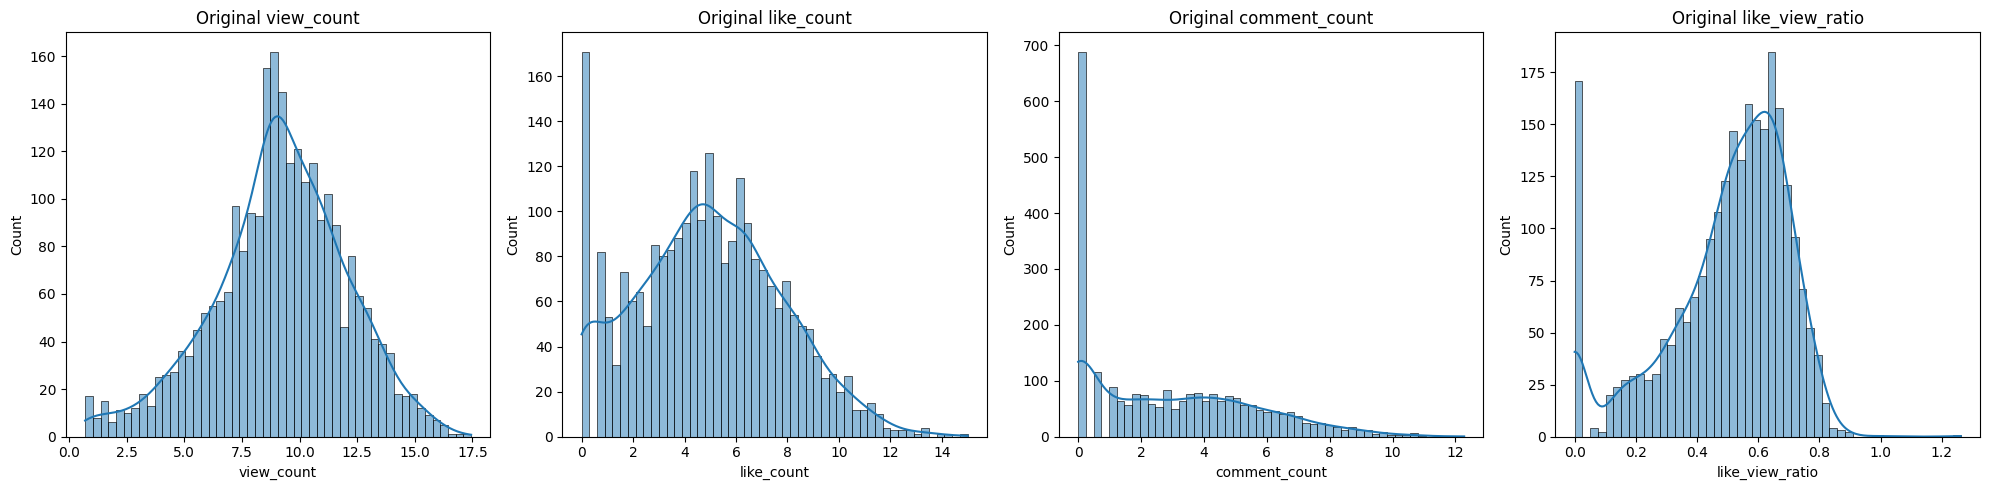

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(['view_count', 'like_count', 'comment_count', 'like_view_ratio']):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Original {col}')

plt.tight_layout()
plt.show()

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler



structured_features = [
    'title_sentiment', 'is_clickbait', 'has_number', 'has_punctuation',
    'publish_hour', 'publish_weekday', 'is_weekday', 'publish_month', 'is_holiday',
    'cluster', 'tag_count', 'duration_seconds'
]

X_struct = df[structured_features].fillna(0).values

threshold = df['like_view_ratio'].mean()
df['label'] = (df['like_view_ratio'] > threshold).astype(int)
y = df['label'].values
X_all = np.hstack([X_struct])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LogisticRegression_Default": LogisticRegression(max_iter=1000),
    "LogisticRegression_L2": LogisticRegression(penalty='l2', C=0.5, solver='liblinear', max_iter=1000)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:05:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1
0,RandomForest,0.721893,0.734247,0.858974,0.791728
1,XGBoost,0.708087,0.734286,0.823718,0.776435
2,LogisticRegression_Default,0.666667,0.699164,0.804487,0.748137
3,LogisticRegression_L2,0.664694,0.696133,0.807692,0.747774


Since we didn't analyze and put text data in the model, we can find that the results are not that good.

Later, we will add text data and improve our model.

In [ ]:
# !pip install -q sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
import numpy as np
from sentence_transformers import SentenceTransformer

df = pd.read_csv("cleaned_FE_data.csv")
df.info()

for col in ['description_clean', 'tags_clean', 'text']:
    df[col] = df[col].fillna("")

text_model = SentenceTransformer('all-MiniLM-L6-v2')
X_text = text_model.encode(df['text'].tolist(), show_progress_bar=True)
X_desc = text_model.encode(df['description_clean'].tolist(), show_progress_bar=True)
X_tags = text_model.encode(df['tags_clean'].tolist(), show_progress_bar=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2531 entries, 0 to 2530
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   video_id            2531 non-null   object 
 1   title               2531 non-null   object 
 2   description         2392 non-null   object 
 3   published_at        2531 non-null   object 
 4   channel_id          2531 non-null   object 
 5   channel_title       2531 non-null   object 
 6   tags                2531 non-null   object 
 7   view_count          2531 non-null   float64
 8   like_count          2531 non-null   float64
 9   comment_count       2531 non-null   float64
 10  duration            2531 non-null   object 
 11  category_id         2531 non-null   int64  
 12  live_broadcast      2531 non-null   object 
 13  subscriber_count    2531 non-null   int64  
 14  video_count         2531 non-null   int64  
 15  view_count_total    2531 non-null   int64  
 16  has_de

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/80 [00:00<?, ?it/s]

Batches:   0%|          | 0/80 [00:00<?, ?it/s]

Batches:   0%|          | 0/80 [00:00<?, ?it/s]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

structured_features = [
    'title_sentiment', 'is_clickbait', 'has_number', 'has_punctuation',
    'publish_hour', 'publish_weekday', 'is_weekday', 'publish_month', 'is_holiday',
    'cluster', 'tag_count', 'duration_seconds'
]

X_struct = df[structured_features].fillna(0).values
# df[structured_features].info()
threshold = df['like_view_ratio'].mean()
df['label'] = (df['like_view_ratio'] > threshold).astype(int)
y = df['label'].values

# Number of each lables
print(df['label'].value_counts())

# Do SMOTE to balance the samples
smote = SMOTE(random_state=42)
scaler = StandardScaler()
X_struct_scaled = scaler.fit_transform(X_struct)
X_all = np.hstack([X_text, X_struct_scaled])


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


# Define models

param_grids = {
    "RandomForest": {
        "n_estimators": [100, 300],
        "max_depth": [5, 10],
        "min_samples_leaf": [1, 3]
    },
    "XGBoost": {
        "n_estimators": [100, 300],
        "max_depth": [5, 10],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8],
        "colsample_bytree": [0.8]
    },
    "LogisticRegression_L2": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ['liblinear'],
        "penalty": ['l2'],
        "max_iter": [1000]
    }
}


models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LogisticRegression_L2": LogisticRegression()
}

results = []
for name, model in models.items():
    print('-----',name,'-----')

    grid_search = GridSearchCV(model, param_grids[name], scoring='f1', cv=5, verbose=1, n_jobs=-1)
    grid_search.fit(X_train_resampled, y_train_resampled)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    results.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "Best F1 Score (CV)": grid_search.best_score_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

#---------------------------------------------
# -----------------regression-----------------
#---------------------------------------------

# models = {
#     "RandomForest": RandomForestRegressor(
#         n_estimators=150,
#         max_depth=20,
#         min_samples_leaf=10,
#         max_features='sqrt',
#         random_state=42,
#         n_jobs=-1
#     ),
#     "XGBoost": XGBRegressor(
#         n_estimators=100,
#         learning_rate=0.05,
#         max_depth=15,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         random_state=42,
#         n_jobs=-1
#     ),
#    "LinearRegression": LinearRegression()
# }
# Train and evaluate
# results = []
# for name, model in models.items():
#     model.fit(X_train, y_train)
#     for split, X_split, y_split in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
#         y_pred = model.predict(X_split)
#         mae = mean_absolute_error(y_split, y_pred)
#         rmse = np.sqrt(mean_squared_error(y_split, y_pred))
#         r2 = r2_score(y_split, y_pred)
#         results.append({
#             "Model": name,
#             "Dataset": split,
#             "MAE": mae,
#             "RMSE": rmse,
#             "R2": r2
#         })

label
1    1522
0    1009
Name: count, dtype: int64
----- RandomForest -----
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----- XGBoost -----
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----- LogisticRegression_L2 -----
Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [ ]:
print(results_df[["Model", "Best F1 Score (CV)", "Accuracy", "Precision", "Recall", "F1"]].to_string(index=False))

print('-------------------------')

print(results_df[["Model", "Best Params"]].to_string(index=False))

                Model  Best F1 Score (CV)  Accuracy  Precision   Recall       F1
         RandomForest            0.775018  0.721893   0.764706 0.791667 0.777953
              XGBoost            0.799026  0.731755   0.780255 0.785256 0.782748
LogisticRegression_L2            0.712797  0.692308   0.765306 0.721154 0.742574
-------------------------
                Model                                                                                             Best Params
         RandomForest                                           {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300}
              XGBoost {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}
LogisticRegression_L2                                     {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}


1. We use SentenceTransformer (MiniLM) to transform 'text', 'description_clean', 'tags_clean' into semantic vectors (each sample becomes 384 dimensions).

  In this part, each text (no matter how long or short) is converted into a fixed-length vector. These embedding vectors capture features such as semantic similarity, context, and meaning of the text, which can be used in later model.

2. Then, we divide like_view_ratio into two categories based on the average;
  
  Greater than average is set to 1 (high interaction), otherwise 0 (low interaction)

3. Then, do standardization on numerical features. Splicing text embeddings with standardized features into final input features.

4. Imbalance in treatment categories. Since we use average number of like_view_ratio to distinguish high or low engagment, the number of positive and negative samples is unbalanced (1522 vs 1009).

 In order for subsequent analyses not to be skewed by the categories, we do SMOTE sampling to the training set to complement the few class samples.

 Improving the model's ability to recognize positive and negative samples and mitigating the bias toward the majority class

5. Then, we trying to compare three models and get parametric search space for each. Hyperparameter optimization by means of grid searching.




